# Casting defects - what the dataset contains

Front-view photographs of cast impellers, two classes, in a train and a test
folder the dataset ships already split. Module 03 of the Arkon platform trains on
them and feeds the Quality Steering Cell through the risk event adapter.

This notebook asks what is in those folders before anything is fitted. Every
image is opened rather than a sample of them, and the counts are checked against
the metrics file the shipped run wrote.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries, the paths and the two class names. Paths stay relative so no local drive layout is printed into a public repository.

In [2]:
import hashlib
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/03_casting/raw')
META_PATH = Path('../../../models/checkpoints/casting/casting_cv_meta.json')

DEFECT_CLASS = 'def_front'
GOOD_CLASS = 'ok_front'

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'pillow  {Image.__version__}')
print(f'raw folder present: {RAW_DIR.is_dir()}   metrics file present: {META_PATH.is_file()}')

python  3.12.10
pandas  2.3.3
pillow  12.2.0
raw folder present: True   metrics file present: True


## 2. One scan, and everything after it is a query

Fifty files cannot describe seven thousand, so every image is opened once. This
cell records size, mode, channel structure, brightness and two content hashes for
all of them, and every section below queries that one table instead of reading
the disk again.

In [3]:
def scan(root):
    """Open every image under root/<split>/<class> once and record what it is."""
    rows = []
    for split in ('train', 'test'):
        for folder in sorted(p for p in (root / split).iterdir() if p.is_dir()):
            for path in sorted(folder.iterdir()):
                raw = path.read_bytes()
                with Image.open(path) as image:
                    width, height = image.size
                    mode, fmt = image.mode, image.format
                    colour = np.asarray(image)
                    grey = np.asarray(image.convert('L'))
                identical = (colour.ndim == 3 and colour.shape[2] == 3
                             and np.array_equal(colour[..., 0], colour[..., 1])
                             and np.array_equal(colour[..., 1], colour[..., 2]))
                rows.append({
                    'split': split, 'label': folder.name, 'name': path.name,
                    'bytes': len(raw), 'width': width, 'height': height,
                    'mode': mode, 'format': fmt, 'channels_identical': bool(identical),
                    'mean_intensity': float(grey.mean()),
                    'std_intensity': float(grey.std()),
                    'file_sha': hashlib.sha256(raw).hexdigest(),
                    'pixel_sha': hashlib.sha256(grey.tobytes()).hexdigest(),
                })
    return pd.DataFrame(rows)


t0 = time.time()
images = scan(RAW_DIR)
print(f'{len(images):,} files opened in {time.time() - t0:.1f}s')
print(images[['split', 'label', 'name', 'bytes', 'width', 'height', 'mode',
              'mean_intensity']].head(3).to_string(index=False))

7,348 files opened in 11.4s
split     label                 name  bytes  width  height mode  mean_intensity
train def_front    cast_def_0_0.jpeg   9129    300     300  RGB      132.115467
train def_front cast_def_0_1000.jpeg   9984    300     300  RGB      135.552589
train def_front cast_def_0_1001.jpeg   9112    300     300  RGB      139.761133


## 3. Do the folders match what the shipped run recorded

The metrics file records a training, a validation and a test count. The first two
are the halves of the train folder, so the folder total has to equal their sum.
This cell checks that it does.

In [4]:
counts = (images.groupby(['split', 'label']).size()
          .unstack(fill_value=0)[[DEFECT_CLASS, GOOD_CLASS]])
counts['total'] = counts.sum(axis=1)
print(counts.to_string())
print()

meta = json.loads(META_PATH.read_text(encoding='utf-8'))
recorded = {'train folder': meta['train_images'] + meta['validation_images'],
            'test folder': meta['test_images']}
here = {'train folder': int(counts.loc['train', 'total']),
        'test folder': int(counts.loc['test', 'total'])}

print(f'{"":<14}{"on disk":>10}{"recorded":>10}{"delta":>8}')
for key in recorded:
    print(f'{key:<14}{here[key]:>10,}{recorded[key]:>10,}{here[key] - recorded[key]:>8}')
print(f'{"total":<14}{sum(here.values()):>10,}{sum(recorded.values()):>10,}'
      f'{sum(here.values()) - sum(recorded.values()):>8}')
print(f'\nthe train folder is split {meta["train_images"]:,} / {meta["validation_images"]:,} '
      f'at seed {meta["seed"]}, and notebook 02 rebuilds that split')

label  def_front  ok_front  total
split                            
test         453       262    715
train       3758      2875   6633

                 on disk  recorded   delta
train folder       6,633     6,633       0
test folder          715       715       0
total              7,348     7,348       0

the train folder is split 5,638 / 995 at seed 42, and notebook 02 rebuilds that split


## 4. Image properties, measured on all of them

Two questions fifty files could not answer: is every image the same shape, and are these really colour photographs.

In [5]:
print('shape      ', images.groupby(['width', 'height']).size().to_dict())
print('mode       ', images['mode'].value_counts().to_dict())
print('format     ', images['format'].value_counts().to_dict())
print('channels   ', f'R == G == B in {images["channels_identical"].sum():,} of {len(images):,} images')
print('file size  ', f'{images["bytes"].min():,} to {images["bytes"].max():,} bytes, '
                     f'median {int(images["bytes"].median()):,}')

shape       {(300, 300): 7348}
mode        {'RGB': 7348}
format      {'JPEG': 7348}
channels    R == G == B in 7,348 of 7,348 images
file size   8,119 to 12,251 bytes, median 9,882


The answer to the second one is no, and it is worth naming. The images are
greyscale stored in three identical channels, while the pipeline normalises with
the ImageNet per-channel constants, so three copies of one number leave the
transform as three different ones. Notebook 02 measures what that does. It
matters here because a reader of the model card sees "300 x 300 RGB" and
reasonably assumes colour carries information.

## 5. Class balance

The two folders do not have to share a class ratio. This cell checks whether they do, and draws the counts.

per cent of the folder
label  def_front  ok_front
split                     
test        63.4      36.6
train       56.7      43.3

the test folder is +6.7 points more defective than the train folder


  ✓ Saved → assets\cv\casting_eda_class_counts.png


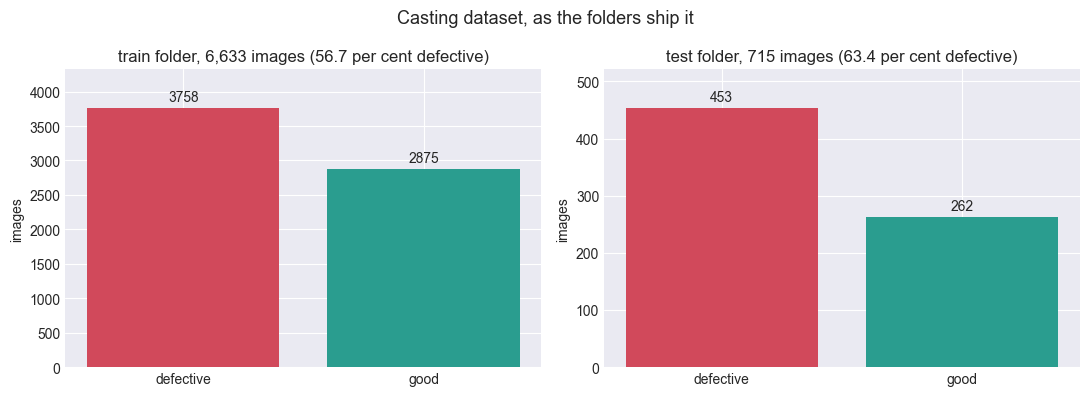

In [6]:
share = (counts[[DEFECT_CLASS, GOOD_CLASS]]
         .div(counts['total'], axis=0) * 100).round(1)
print('per cent of the folder')
print(share.to_string())
print(f'\nthe test folder is {share.loc["test", DEFECT_CLASS] - share.loc["train", DEFECT_CLASS]:+.1f} '
      f'points more defective than the train folder')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split in zip(axes, ('train', 'test')):
    values = [int(counts.loc[split, DEFECT_CLASS]), int(counts.loc[split, GOOD_CLASS])]
    bars = ax.bar(['defective', 'good'], values, color=['#d1495b', '#2a9d8f'])
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_title(f'{split} folder, {int(counts.loc[split, "total"]):,} images '
                 f'({share.loc[split, DEFECT_CLASS]:.1f} per cent defective)')
    ax.set_ylabel('images')
    ax.set_ylim(0, max(values) * 1.15)
fig.suptitle('Casting dataset, as the folders ship it', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_eda_class_counts', subfolder=ASSETS)
plt.show()

## 6. The duplicate census

The whole reported performance rests on the train and test folders being
disjoint, and nothing in this repository had ever checked it. The scan already
carries both hashes, so the check costs one groupby. Equal file bytes would mean
a copied file; equal pixels but different bytes would mean a re-encoding.

In [7]:
def duplicate_groups(frame, column):
    """Every set of rows sharing a hash, keyed by that hash."""
    sizes = frame.groupby(column).size()
    return {key: frame[frame[column] == key] for key in sizes[sizes > 1].index}


by_bytes = duplicate_groups(images, 'file_sha')
by_pixels = duplicate_groups(images, 'pixel_sha')

print(f'{"hashed on":<18}{"unique":>9}{"groups":>9}{"extra copies":>14}')
for tag, column, groups in (('file bytes', 'file_sha', by_bytes),
                            ('decoded pixels', 'pixel_sha', by_pixels)):
    extra = sum(len(g) - 1 for g in groups.values())
    print(f'{tag:<18}{images[column].nunique():>9,}{len(groups):>9,}{extra:>14,}')

if len(by_bytes) == len(by_pixels):
    print('\nthe two agree, so every duplicate is a copied file rather than a re-encoded photograph')
else:
    print('\nthe two disagree: some images are the same picture stored differently')

hashed on            unique   groups  extra copies
file bytes            7,284       64            64
decoded pixels        7,284       64            64

the two agree, so every duplicate is a copied file rather than a re-encoded photograph


Where the copies sit matters more than how many there are: across the two splits or inside one, same class or in conflict, and whether they even share a filename.

In [8]:
rows = []
for group in by_pixels.values():
    rows.append({'copies': len(group),
                 'splits': ' + '.join(sorted(group['split'].unique())),
                 'labels': ' + '.join(sorted(group['label'].unique())),
                 'same_filename': group['name'].nunique() == 1})
groups = pd.DataFrame(rows)

print('duplicate groups by where the copies sit')
print(groups.groupby(['splits', 'labels', 'copies', 'same_filename'])
      .size().rename('groups').to_frame().to_string())
print(f'\ngroups holding both a defective and a good copy (a label conflict): '
      f'{int(groups["labels"].str.contains(r" \+ ").sum())}')

duplicate groups by where the copies sit
                                            groups
splits       labels   copies same_filename        
test + train ok_front 2      True               64

groups holding both a defective and a good copy (a label conflict): 0


And what it costs, per class, against the counts the model card reports.

In [9]:
leaked = pd.concat([g[g['split'] == 'test'] for g in by_pixels.values()])
test_rows = images[images['split'] == 'test']

print(f'{"":<26}{"leaked":>8}{"in test":>9}{"per cent":>10}')
for label in (DEFECT_CLASS, GOOD_CLASS):
    total = int((test_rows['label'] == label).sum())
    hit = int((leaked['label'] == label).sum())
    print(f'{"test " + label:<26}{hit:>8}{total:>9}{100 * hit / total:>9.1f}%')
print(f'{"test folder overall":<26}{len(leaked):>8}{len(test_rows):>9}'
      f'{100 * len(leaked) / len(test_rows):>9.1f}%')

point = meta['operating_points']['missed_defect_costs_25x']
scored_good = point['good_parts_passed'] + point['good_parts_rejected']
print(f'\nthe shipped operating point calls {point["good_parts_rejected"]} of those '
      f'{scored_good} good parts a false alarm,')
print(f'and {len(leaked)} of the {scored_good} were in the training folder.')

                            leaked  in test  per cent
test def_front                   0      453      0.0%
test ok_front                   64      262     24.4%
test folder overall             64      715      9.0%

the shipped operating point calls 7 of those 262 good parts a false alarm,
and 64 of the 262 were in the training folder.


**The leak is one-sided, which is why it does not make the card simply wrong.**
It lands entirely on the good parts, the class the false-alarm count is made of,
and not at all on the defects, the class the recall claim is made of.

- **Recall, 0 defects missed of 453**, is measured on defects the model has never
  seen. The leak does not touch it.
- **7 good parts rejected of 262** is measured on a set where a quarter of the
  parts sat in the training folder.

Notebook 03 does not argue about the size of that effect. It measures it.

The finding as a picture: what the test folder is made of, and one duplicate pair side by side.

  ✓ Saved → assets\cv\casting_eda_duplicates.png


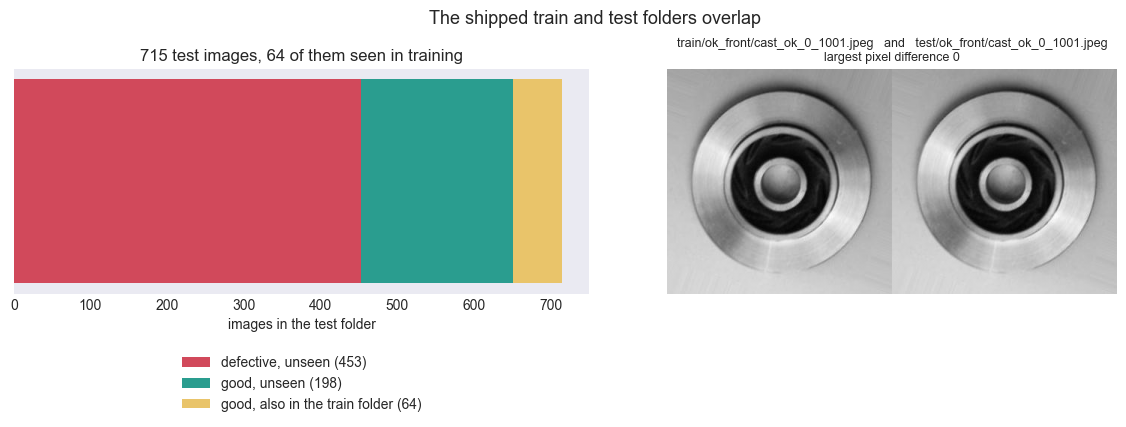

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
leaked_good = int((leaked['label'] == GOOD_CLASS).sum())
clean_good = int((test_rows['label'] == GOOD_CLASS).sum()) - leaked_good
segments = [('defective, unseen', int((test_rows['label'] == DEFECT_CLASS).sum()), '#d1495b'),
            ('good, unseen', clean_good, '#2a9d8f'),
            ('good, also in the train folder', leaked_good, '#e9c46a')]
left = 0
for name, value, colour in segments:
    ax.barh([0], [value], left=left, color=colour, label=f'{name} ({value})')
    left += value
ax.set_yticks([])
ax.set_xlabel('images in the test folder')
ax.set_title(f'{len(test_rows):,} test images, {len(leaked)} of them seen in training')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=False)
ax.grid(False)

example = sorted(by_pixels.values(), key=lambda g: g['name'].iloc[0])[0]
train_row = example[example['split'] == 'train'].iloc[0]
test_row = example[example['split'] == 'test'].iloc[0]
pair = [np.asarray(Image.open(RAW_DIR / row['split'] / row['label'] / row['name']).convert('L'))
        for row in (train_row, test_row)]
ax = axes[1]
ax.imshow(np.hstack(pair), cmap='gray', vmin=0, vmax=255)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title(f'train/{train_row["label"]}/{train_row["name"]}   and   '
             f'test/{test_row["label"]}/{test_row["name"]}\n'
             f'largest pixel difference '
             f'{int(np.abs(pair[0].astype(int) - pair[1].astype(int)).max())}',
             fontsize=9)

fig.suptitle('The shipped train and test folders overlap', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_eda_duplicates', subfolder=ASSETS)
plt.show()

## 7. How separable is this before any model

Limitation 1 of the model card says the problem is nearly solved by the data
rather than by the network. One number per image can test that: take the mean
brightness of each photograph and use it as the entire classifier.

In [11]:
test_truth = (test_rows['label'] == DEFECT_CLASS).astype(int).to_numpy()

print(f'{"one-number classifier":<34}{"ROC AUC":>9}')
for feature in ('mean_intensity', 'std_intensity'):
    auc = roc_auc_score(test_truth, test_rows[feature].to_numpy())
    direction = 'higher means defective' if auc >= 0.5 else 'lower means defective'
    print(f'{feature:<34}{max(auc, 1 - auc):>9.4f}   ({direction})')
print(f'{"fine-tuned ResNet-18 (metrics file)":<34}'
      f'{meta["at_threshold_0.5"]["roc_auc"]:>9.4f}')

one-number classifier               ROC AUC
mean_intensity                       0.8655   (lower means defective)
std_intensity                        0.8186   (lower means defective)
fine-tuned ResNet-18 (metrics file)   0.9999


The same thing drawn: where the two classes sit on brightness, and how far that single number gets against the network.

  ✓ Saved → assets\cv\casting_eda_intensity.png


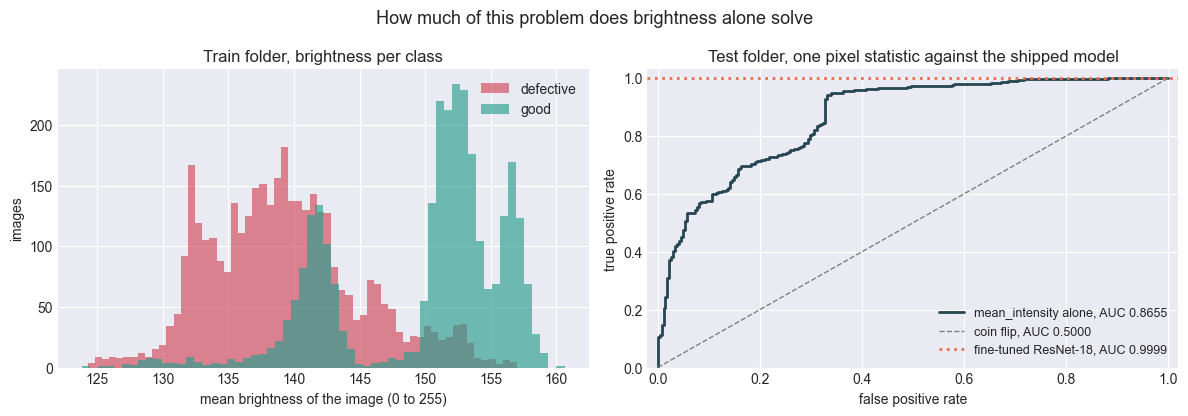

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

train_rows = images[images['split'] == 'train']
ax = axes[0]
for label, colour, name in ((DEFECT_CLASS, '#d1495b', 'defective'),
                            (GOOD_CLASS, '#2a9d8f', 'good')):
    ax.hist(train_rows.loc[train_rows['label'] == label, 'mean_intensity'],
            bins=60, alpha=0.65, color=colour, label=name)
ax.set_xlabel('mean brightness of the image (0 to 255)')
ax.set_ylabel('images')
ax.set_title('Train folder, brightness per class')
ax.legend()

ax = axes[1]
scored = {f: roc_auc_score(test_truth, test_rows[f].to_numpy())
          for f in ('mean_intensity', 'std_intensity')}
best_feature = max(scored, key=lambda f: max(scored[f], 1 - scored[f]))
values, auc = test_rows[best_feature].to_numpy(), scored[best_feature]
if auc < 0.5:
    values, auc = -values, 1 - auc
fpr, tpr, _ = roc_curve(test_truth, values)
ax.plot(fpr, tpr, color='#264653', linewidth=2, label=f'{best_feature} alone, AUC {auc:.4f}')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1, label='coin flip, AUC 0.5000')
ax.axhline(1.0, color='#e76f51', linewidth=2, linestyle=':',
           label=f'fine-tuned ResNet-18, AUC {meta["at_threshold_0.5"]["roc_auc"]:.4f}')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, 1.03)
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('Test folder, one pixel statistic against the shipped model')
ax.legend(loc='lower right', fontsize=9)

fig.suptitle('How much of this problem does brightness alone solve', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_eda_intensity', subfolder=ASSETS)
plt.show()

## 8. What the images look like

Six of each class, so the fixed rig and fixed lighting behind every number above are visible.

  ✓ Saved → assets\cv\casting_eda_samples.png


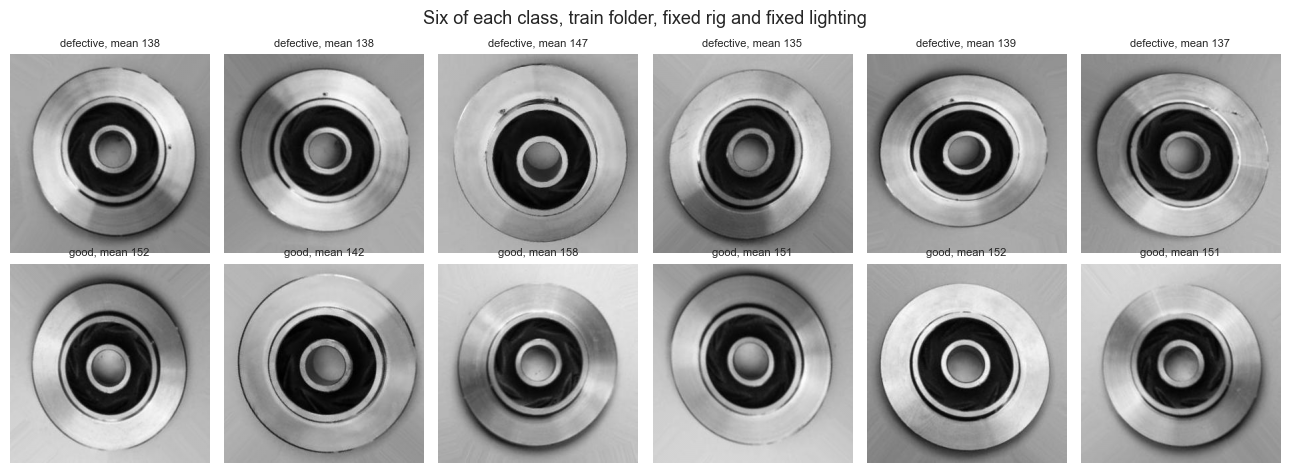

In [13]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 6, figsize=(13, 4.8))
for row, (label, name) in enumerate(((DEFECT_CLASS, 'defective'), (GOOD_CLASS, 'good'))):
    pool = train_rows[train_rows['label'] == label]
    picks = pool.iloc[rng.choice(len(pool), 6, replace=False)]
    for ax, (_, item) in zip(axes[row], picks.iterrows()):
        ax.imshow(np.asarray(Image.open(RAW_DIR / 'train' / label / item['name']).convert('L')),
                  cmap='gray', vmin=0, vmax=255)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f'{name}, mean {item["mean_intensity"]:.0f}', fontsize=8)
fig.suptitle('Six of each class, train folder, fixed rig and fixed lighting', fontsize=13)
fig.tight_layout()
save_figure(fig, 'casting_eda_samples', subfolder=ASSETS)
plt.show()

## 9. What this notebook found

Printed from the scan rather than typed, so the sentences cannot drift away from it.

In [14]:
brightness_auc = max(scored['mean_intensity'], 1 - scored['mean_intensity'])
good_in_test = int((test_rows['label'] == GOOD_CLASS).sum())

print(f'1. The folder counts reproduce the shipped run exactly: {len(images):,} images, '
      f'{int(counts.loc["train", "total"]):,} in the train folder and '
      f'{int(counts.loc["test", "total"]):,} in the test folder.')
print(f'2. Every image is {images["width"].iloc[0]} x {images["height"].iloc[0]}, '
      f'{images["format"].iloc[0]}, and greyscale in all {images["channels_identical"].sum():,} '
      f'of them despite being stored as three channels.')
print(f'3. The shipped train and test folders are NOT disjoint. {len(by_pixels)} test images are '
      f'byte-identical copies of training images, all of them good parts: {leaked_good} of the '
      f'{good_in_test} good parts in the test folder, {100 * leaked_good / good_in_test:.1f} per '
      f'cent. No defect is duplicated, so recall is unaffected and the false-alarm count is not.')
print(f'4. Mean brightness alone reaches ROC AUC {brightness_auc:.4f} on the test folder against '
      f'{meta["at_threshold_0.5"]["roc_auc"]:.4f} for the fine-tuned network. The network is worth '
      f'the difference, and the difference is where limitation 1 of the model card lives.')
print(f'\nNotebook 02 rebuilds the train and validation split and measures the transforms. '
      f'Notebook 03 trains the model and measures item 3 against the operating point.')

1. The folder counts reproduce the shipped run exactly: 7,348 images, 6,633 in the train folder and 715 in the test folder.
2. Every image is 300 x 300, JPEG, and greyscale in all 7,348 of them despite being stored as three channels.
3. The shipped train and test folders are NOT disjoint. 64 test images are byte-identical copies of training images, all of them good parts: 64 of the 262 good parts in the test folder, 24.4 per cent. No defect is duplicated, so recall is unaffected and the false-alarm count is not.
4. Mean brightness alone reaches ROC AUC 0.8655 on the test folder against 0.9999 for the fine-tuned network. The network is worth the difference, and the difference is where limitation 1 of the model card lives.

Notebook 02 rebuilds the train and validation split and measures the transforms. Notebook 03 trains the model and measures item 3 against the operating point.
